# iaCarne — EDA inicial

## 1. Objetivo
Explorar vendas, preços, estoque e perdas do **dataset sintético oficial 1.0.0**, sem treinar modelos. As observações não são vendas reais. Fonte operacional exclusiva: CSV tratado pelo ETL. Ground truth não é carregado. A análise descreve padrões da simulação, sem demonstrar efeitos causais ou benefícios ambientais.

## 2. Bibliotecas e caminhos
Executar com o kernel do ambiente documentado. O notebook aceita execução a partir da raiz ou da pasta notebooks.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd().resolve()
if not (ROOT / "pipeline").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "pipeline").is_dir(), "Execute a partir da raiz ou de notebooks"
FIG = ROOT / "reports/figures"
FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.figsize": (10, 5), "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.18, "font.size": 11})
def save(name):
    plt.tight_layout()
    plt.savefig(FIG / name, dpi=140, bbox_inches="tight")
    plt.show()


## 3. Carregamento e procedência
Eventos vazios são ausência de evento selecionado. `keep_default_na=False` preserva esse significado; os outros campos já foram validados pelo ETL.

In [2]:
df = pd.read_csv(ROOT / "data/processed/iacarne_vendas_tratado.csv", parse_dates=["data"], keep_default_na=False)
quality = json.loads((ROOT / "data/processed/relatorio_pipeline.json").read_text(encoding="utf-8"))
assert "demanda_latente_kg" not in df.columns
assert quality["versao_dataset"] == "1.0.0"
print("Versão:", quality["versao_dataset"], "| SHA-256 bruto:", quality["sha256_entrada"])

import hashlib
assert hashlib.sha256((ROOT / "data/processed/iacarne_vendas_tratado.csv").read_bytes()).hexdigest() == quality["sha256_saida"], "CSV tratado não corresponde ao relatório; execute novamente o ETL"


Versão: 1.0.0 | SHA-256 bruto: 96fff3c7dfbba9c0b92a42f2853bb86a1212af56c0513e940175cf53519a3694


## 4. Dimensões e cobertura

In [3]:
print(f"{len(df):,} linhas; {df.shape[1]} colunas; {df.produto_id.nunique()} cortes; {df.data.nunique()} dias")
print("Período:", df.data.min().date(), "a", df.data.max().date())
assert len(df) == 7665 and df.produto_id.nunique() == 21 and df.data.nunique() == 365


7,665 linhas; 28 colunas; 21 cortes; 365 dias
Período: 2025-09-01 a 2026-08-31


## 5. Tipos

In [4]:
display(df.dtypes.astype(str).rename("tipo").to_frame())

,tipo
registro_id,object
data,datetime64[ns]
produto_id,object
corte,object
categoria_anatomica,object
perfil_uso,object
preco_venda_kg,float64
promocao,int64
desconto_pct,float64
estoque_inicial_kg,float64


## 6. Inspeção inicial

In [5]:
display(df.head(7))

,registro_id,data,produto_id,corte,categoria_anatomica,perfil_uso,preco_venda_kg,promocao,desconto_pct,estoque_inicial_kg,...,custo_total_estimado_rs,margem_bruta_estimada_rs,dia_semana,fim_de_semana,evento_calendario,mes,ano,semana_ano,estoque_inicial_reconstruido,ano_semana_iso
0,2025-09-01_acem,2025-09-01,acem,Acém,dianteiro,dia_a_dia,37.40,0,0.0,0.0,...,507.32,248.91,segunda,0,,9,2025,36,0,2025
1,2025-09-01_alcatra,2025-09-01,alcatra,Alcatra,traseiro,churrasco,52.94,0,0.0,0.0,...,543.17,307.58,segunda,0,,9,2025,36,0,2025
2,2025-09-01_capa_file,2025-09-01,capa_file,Capa de Filé,dianteiro,churrasco,42.08,0,0.0,0.0,...,210.98,94.10,segunda,0,,9,2025,36,0,2025
3,2025-09-01_costelao,2025-09-01,costelao,Costelão,costela,churrasco,28.10,0,0.0,0.0,...,315.64,168.24,segunda,0,,9,2025,36,0,2025
4,2025-09-01_coxao_duro,2025-09-01,coxao_duro,Coxão Duro,traseiro,dia_a_dia,40.85,0,0.0,0.0,...,310.65,126.04,segunda,0,,9,2025,36,0,2025
5,2025-09-01_coxao_mole,2025-09-01,coxao_mole,Coxão Mole,traseiro,dia_a_dia,47.91,0,0.0,0.0,...,519.29,263.56,segunda,0,,9,2025,36,0,2025
6,2025-09-01_cupim,2025-09-01,cupim,Cupim,dianteiro,churrasco,48.61,0,0.0,0.0,...,224.22,108.27,segunda,0,,9,2025,36,0,2025


## 7. Nulos e correções
Os campos obrigatórios devem estar completos. Ausência de evento não é imputada como evento desconhecido.

In [6]:
display(df.isna().sum().rename("nulos").to_frame())
print("Dias/corte sem evento:", df.evento_calendario.eq("").sum())
print("Correções:", quality["transformacoes"])
assert not df.isna().any().any()


,nulos
registro_id,0
data,0
produto_id,0
corte,0
categoria_anatomica,0
perfil_uso,0
preco_venda_kg,0
promocao,0
desconto_pct,0
estoque_inicial_kg,0


Dias/corte sem evento: 7413
Correções: {'calendario_corrigido': 0, 'estoques_reconstruidos': 23, 'nomes_padronizados': 38, 'precos_convertidos': 19}


## 8. Duplicatas
A chave natural é data/produto, além de registro_id.

In [7]:
print("Duplicatas removidas:", quality["duplicatas_removidas"])
assert not df.registro_id.duplicated().any()
assert not df.duplicated(["data", "produto_id"]).any()


Duplicatas removidas: 15


## 9. Estatísticas descritivas
Os valores de custo e margem são estimativas sintéticas, não contabilidade real.

In [8]:
metrics = ["quantidade_vendida_kg", "preco_venda_kg", "receita_bruta_rs", "estoque_inicial_kg", "estoque_final_kg", "perda_kg"]
display(df[metrics].describe().round(2))


,quantidade_vendida_kg,preco_venda_kg,receita_bruta_rs,estoque_inicial_kg,estoque_final_kg,perda_kg
count,7665.00,7665.00,7665.00,7665.00,7665.00,7665.00
mean,14.91,47.81,688.27,3.02,3.03,0.05
std,6.55,16.50,314.01,2.77,2.77,0.04
min,4.32,23.86,142.08,0.00,0.00,0.00
25%,10.23,38.27,456.45,0.86,0.87,0.01
50%,13.30,44.44,609.90,2.55,2.55,0.04
75%,18.12,50.43,856.17,4.34,4.35,0.07
max,50.16,112.73,2400.36,23.00,23.00,0.32


## 10. Análise por corte
Comparação do volume acumulado no mesmo período completo para todos os cortes.

,venda_kg,receita_rs,perdas_kg,ruptura_pct,preco_ponderado_rs_kg
corte,,,,,
Acém,10368.51,392856.10,31.81,11.51,37.89
Patinho,8615.34,442773.28,28.92,8.77,51.39
Coxão Mole,7872.08,380218.39,25.96,10.68,48.30
Costelão,7649.80,219405.82,23.79,23.01,28.68
Alcatra,7624.06,391687.41,16.16,23.56,51.38
Paleta,6291.55,251099.72,23.58,12.60,39.91
Coxão Duro,5492.09,231153.02,18.92,9.86,42.09
Fraldinha,5484.85,253034.09,14.04,24.66,46.13
Músculo Dianteiro,5076.59,182288.40,19.25,12.05,35.91


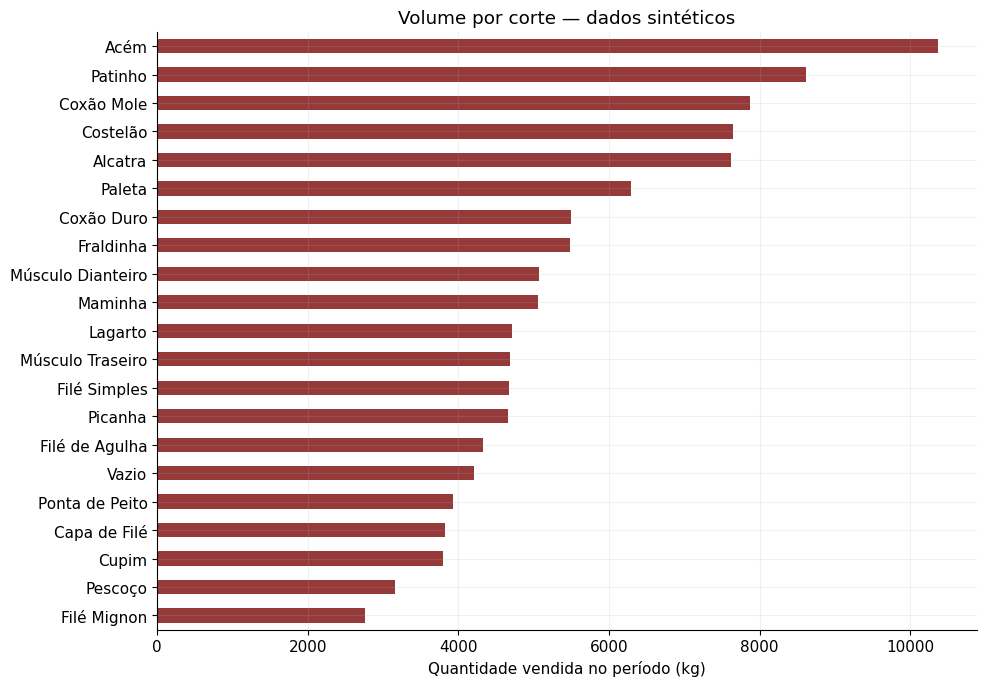

Maior volume: Acém, 10368.51 kg. A ordem reflete também as demandas-base escolhidas no gerador.


In [9]:
by_cut = df.groupby("corte").agg(venda_kg=("quantidade_vendida_kg", "sum"), receita_rs=("receita_bruta_rs", "sum"), perdas_kg=("perda_kg", "sum"), ruptura_pct=("ruptura_estoque", lambda s: 100*s.mean()))
by_cut["preco_ponderado_rs_kg"] = by_cut.receita_rs / by_cut.venda_kg
display(by_cut.sort_values("venda_kg", ascending=False).round(2))
by_cut.venda_kg.sort_values().plot.barh(color="#963939", figsize=(10, 7))
plt.title("Volume por corte — dados sintéticos")
plt.xlabel("Quantidade vendida no período (kg)")
plt.ylabel("")
save("01_volume_por_corte.png")
print(f"Maior volume: {by_cut.venda_kg.idxmax()}, {by_cut.venda_kg.max():.2f} kg. A ordem reflete também as demandas-base escolhidas no gerador.")


## 11. Vendas por período
Totais mensais variam com o número de dias. A média diária permite comparar os meses com menor efeito de duração.

,venda_kg,media_diaria_kg,receita_rs,dias
data,,,,
2025-09-01,8921.68,297.39,396862.60,30
2025-10-01,9737.24,314.10,436261.04,31
2025-11-01,10025.82,334.19,451990.30,30
2025-12-01,11918.55,384.47,542349.65,31
2026-01-01,9185.51,296.31,418888.36,31
2026-02-01,7990.19,285.36,369425.70,28
2026-03-01,9213.84,297.22,427694.16,31
2026-04-01,9170.09,305.67,425482.87,30
2026-05-01,9513.82,306.90,447678.00,31


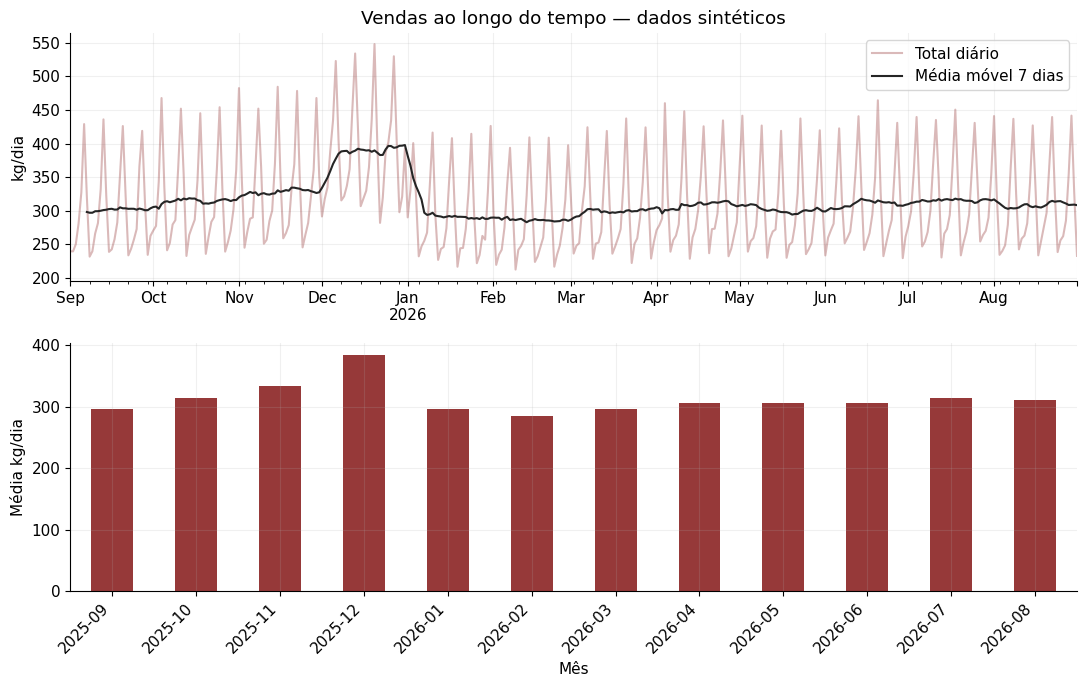

Maior média diária mensal: 2025-12 (384.47 kg/dia). Um ano não demonstra recorrência anual.


In [10]:
daily = df.groupby("data").agg(venda_kg=("quantidade_vendida_kg", "sum"), receita_rs=("receita_bruta_rs", "sum"), estoque_final_kg=("estoque_final_kg", "sum"), perdas_kg=("perda_kg", "sum"))
monthly = daily.resample("MS").agg(venda_kg=("venda_kg", "sum"), media_diaria_kg=("venda_kg", "mean"), receita_rs=("receita_rs", "sum"), dias=("venda_kg", "size"))
display(monthly.round(2))
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
daily.venda_kg.plot(ax=axes[0], alpha=.35, color="#963939", label="Total diário")
daily.venda_kg.rolling(7, min_periods=7).mean().plot(ax=axes[0], color="#252525", label="Média móvel 7 dias")
axes[0].set(title="Vendas ao longo do tempo — dados sintéticos", ylabel="kg/dia", xlabel="")
axes[0].legend()
monthly.media_diaria_kg.plot.bar(ax=axes[1], color="#963939")
axes[1].set_xticklabels(monthly.index.strftime("%Y-%m"), rotation=45, ha="right")
axes[1].set(ylabel="Média kg/dia", xlabel="Mês")
save("02_vendas_temporais.png")
print("Maior média diária mensal:", monthly.media_diaria_kg.idxmax().strftime("%Y-%m"), f"({monthly.media_diaria_kg.max():.2f} kg/dia). Um ano não demonstra recorrência anual.")


## 12. Distribuição de quantidade
A unidade do histograma é dia/corte, não transação ou cliente.

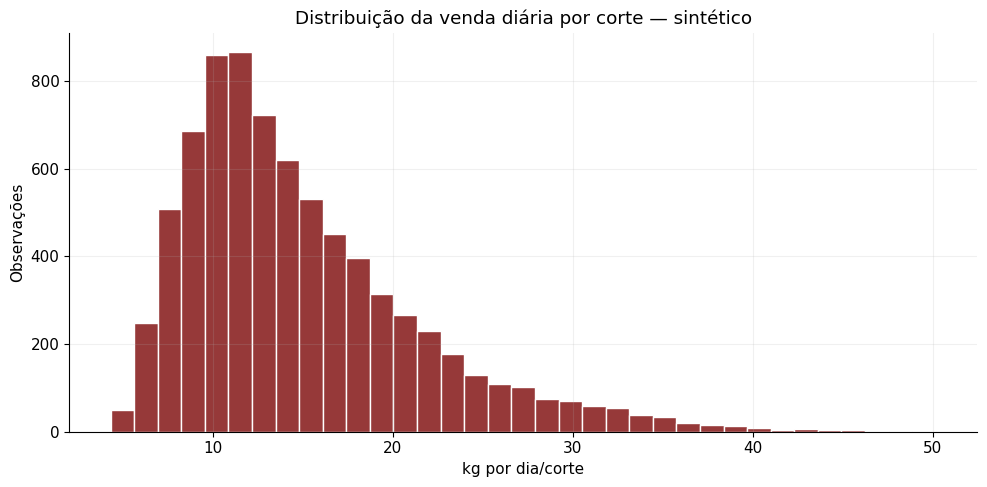

Mediana: 13.30 kg; faixa: 4.32–50.16 kg. A distribuição reúne produtos com demandas-base distintas.


In [11]:
df.quantidade_vendida_kg.plot.hist(bins=35, color="#963939", edgecolor="white")
plt.title("Distribuição da venda diária por corte — sintético")
plt.xlabel("kg por dia/corte")
plt.ylabel("Observações")
save("03_distribuicao_quantidade.png")
print(f"Mediana: {df.quantidade_vendida_kg.median():.2f} kg; faixa: {df.quantidade_vendida_kg.min():.2f}–{df.quantidade_vendida_kg.max():.2f} kg. A distribuição reúne produtos com demandas-base distintas.")


## 13. Preços
Preço realizado ponderado é receita total dividida pelos kg vendidos. Não é a média simples de preços de cortes com volumes diferentes.

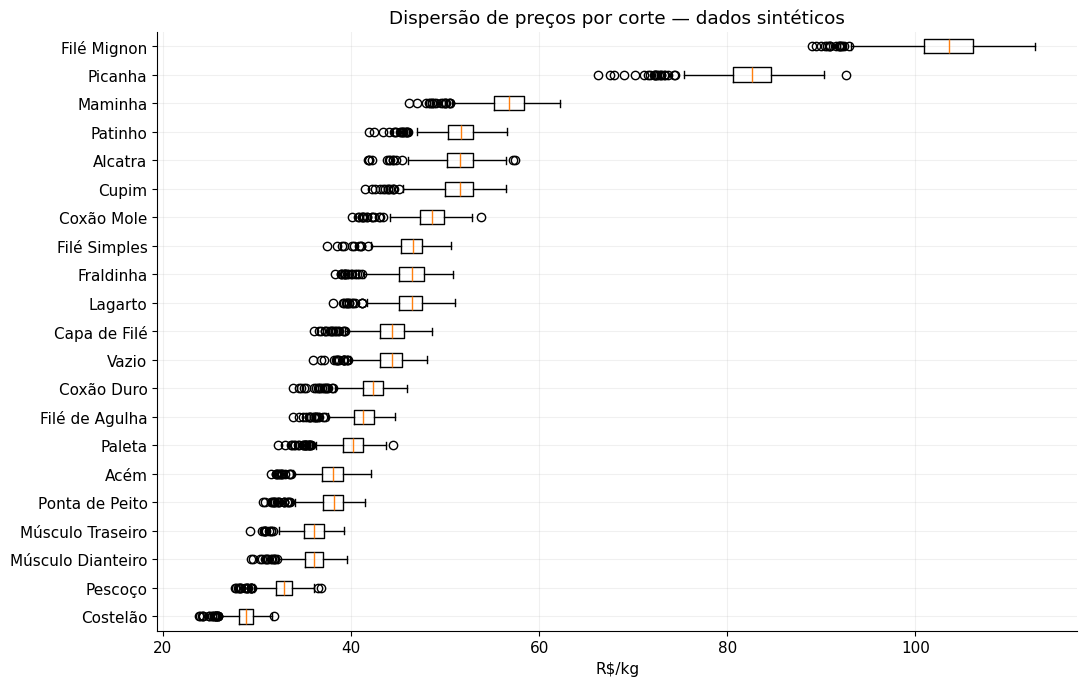

Preço ponderado geral: R$ 46.17/kg. Diferenças entre cortes são em parte premissas de calibração; promoções e tendência também influenciam.


In [12]:
ordered = by_cut.preco_ponderado_rs_kg.sort_values().index
fig, ax = plt.subplots(figsize=(11, 7))
ax.boxplot([df.loc[df.corte.eq(cut), "preco_venda_kg"] for cut in ordered], vert=False, tick_labels=ordered)
ax.set(title="Dispersão de preços por corte — dados sintéticos", xlabel="R$/kg")
save("04_precos_por_corte.png")
print(f"Preço ponderado geral: R$ {df.receita_bruta_rs.sum()/df.quantidade_vendida_kg.sum():.2f}/kg. Diferenças entre cortes são em parte premissas de calibração; promoções e tendência também influenciam.")


## 14. Faturamento
Receita bruta não equivale a lucro; custos estimados não abrangem todas as despesas do negócio.

,valor
venda_kg,114254.29
receita_bruta_rs,5275616.69
custo_estimado_rs,3687644.23
margem_estimada_rs,1587972.46
perdas_kg,371.71
ruptura_pct,16.20


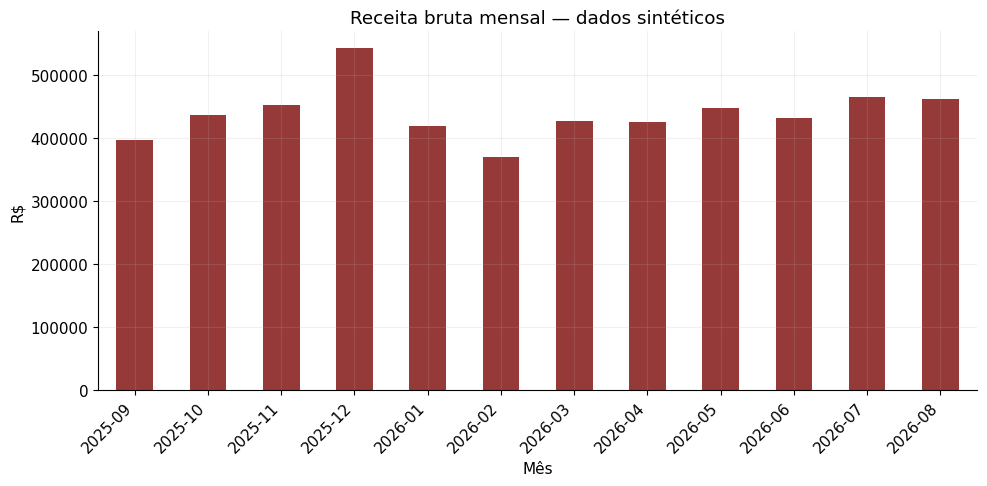

Receita depende simultaneamente de volume, composição dos cortes e preços; o gráfico não permite atribuir a mudança a uma única causa.


In [13]:
summary = {"venda_kg": float(df.quantidade_vendida_kg.sum()), "receita_bruta_rs": float(df.receita_bruta_rs.sum()), "custo_estimado_rs": float(df.custo_total_estimado_rs.sum()), "margem_estimada_rs": float(df.margem_bruta_estimada_rs.sum()), "perdas_kg": float(df.perda_kg.sum()), "ruptura_pct": float(100*df.ruptura_estoque.mean())}
summary = {k: round(v, 4 if k == "ruptura_pct" else 2) for k, v in summary.items()}
display(pd.Series(summary).round(2).rename("valor").to_frame())
fig, ax = plt.subplots(figsize=(10, 5))
monthly.receita_rs.plot.bar(ax=ax, color="#963939")
ax.set_xticklabels(monthly.index.strftime("%Y-%m"), rotation=45, ha="right")
ax.set(title="Receita bruta mensal — dados sintéticos", ylabel="R$", xlabel="Mês")
save("05_receita_mensal.png")
print("Receita depende simultaneamente de volume, composição dos cortes e preços; o gráfico não permite atribuir a mudança a uma única causa.")


## 15. Estoque e rupturas
Somar os 21 cortes de um dia representa o saldo daquele dia. Para períodos, usar médias ou fechamento, não soma dos saldos diários. Venda observada é censurada em parte dos registros.

In [14]:
print(f"Saldo final diário médio: {daily.estoque_final_kg.mean():.2f} kg")
print(f"Saldo final no último dia: {daily.estoque_final_kg.iloc[-1]:.2f} kg")
print(f"Rupturas declaradas: {int(df.ruptura_estoque.sum())} de {len(df)} dias/corte ({summary['ruptura_pct']:.2f}%)")
display(by_cut.ruptura_pct.sort_values(ascending=False).round(2).to_frame())


Saldo final diário médio: 63.55 kg
Saldo final no último dia: 50.46 kg
Rupturas declaradas: 1242 de 7665 dias/corte (16.20%)


,ruptura_pct
corte,
Capa de Filé,28.49
Maminha,27.67
Picanha,25.75
Fraldinha,24.66
Vazio,24.11
Alcatra,23.56
Costelão,23.01
Cupim,22.47
Paleta,12.60


## 16. Perdas
Perdas são fluxo em kg. A razão abaixo usa disponibilidade acumulada por dia/corte como exposição; estoque carregado pode entrar no denominador mais de uma vez. Não é uma taxa sobre compras nem prova de impacto ambiental.

Perdas / disponibilidade acumulada: 0.2697%


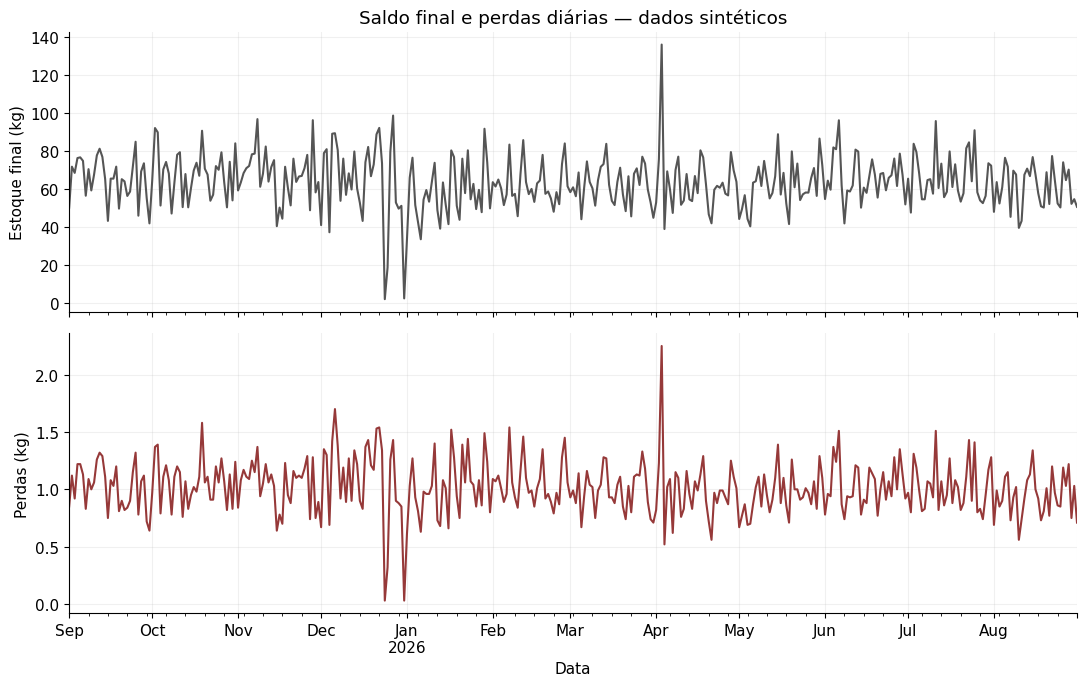

O gerador calcula perdas sobre sobras: associação entre saldo e perda é esperada por construção e não confirma desempenho de uma política real.


In [15]:
loss_rate = 100 * df.perda_kg.sum() / df.estoque_disponivel_kg.sum()
print(f"Perdas / disponibilidade acumulada: {loss_rate:.4f}%")
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
daily.estoque_final_kg.plot(ax=axes[0], color="#555555")
axes[0].set(title="Saldo final e perdas diárias — dados sintéticos", ylabel="Estoque final (kg)")
daily.perdas_kg.plot(ax=axes[1], color="#963939")
axes[1].set(ylabel="Perdas (kg)", xlabel="Data")
save("06_estoque_perdas.png")
print("O gerador calcula perdas sobre sobras: associação entre saldo e perda é esperada por construção e não confirma desempenho de uma política real.")


## 17. Promoções
Comparações são descritivas: mix de produtos, calendário, preço e restrição de estoque confundem o efeito de promoção. A simulação já impõe aumento de demanda durante promoções.

In [16]:
promo = df.groupby("promocao").agg(observacoes=("registro_id", "size"), venda_media_kg=("quantidade_vendida_kg", "mean"), preco_medio_rs_kg=("preco_venda_kg", "mean"), ruptura_pct=("ruptura_estoque", lambda s: 100*s.mean()))
display(promo.round(2))
display(df.groupby(["corte", "promocao"]).quantidade_vendida_kg.mean().unstack().round(2))


,observacoes,venda_media_kg,preco_medio_rs_kg,ruptura_pct
promocao,,,,
0,7130,14.77,48.26,12.71
1,535,16.73,41.84,62.80


promocao,0,1
corte,,
Acém,28.14,31.75
Alcatra,20.69,24.31
Capa de Filé,10.45,10.60
Costelão,20.82,22.55
Coxão Duro,14.89,17.31
Coxão Mole,21.13,28.13
Cupim,10.31,11.52
Filé Mignon,7.48,8.94
Filé Simples,12.72,14.55


## 18. Sazonalidade e calendário
A média por dia da semana controla a diferença no número de observações. Datas especiais são selecionadas pelo simulador, não um calendário completo de feriados.

,media_kg,observacoes,ruptura_pct
dia_semana,,,
segunda,11.45,1113,12.76
terca,12.30,1092,13.19
quarta,13.00,1092,13.10
quinta,13.93,1092,12.91
sexta,16.86,1092,16.48
sabado,21.09,1092,26.83
domingo,15.79,1092,18.22


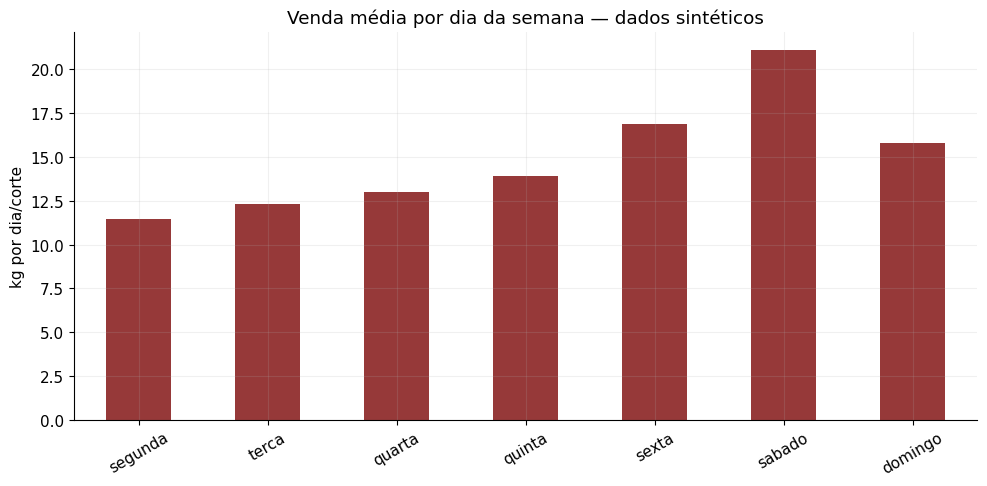

Maior média: sabado ; fatores semanais são explícitos no gerador, portanto não constituem descoberta sobre o mercado real.


,observacoes,media_venda_kg
evento,,
Confraternização Universal,21,13.81
Consciência Negra,21,15.83
Dia do Trabalho,21,17.38
Finados,21,16.63
Independência do Brasil,21,15.24
Natal,21,19.13
Nossa Senhora Aparecida,21,16.86
Proclamação da República,21,23.08
Sexta-feira Santa,21,13.74


In [17]:
order = ["segunda", "terca", "quarta", "quinta", "sexta", "sabado", "domingo"]
weekday = df.groupby("dia_semana").agg(media_kg=("quantidade_vendida_kg", "mean"), observacoes=("registro_id", "size"), ruptura_pct=("ruptura_estoque", lambda s: 100*s.mean())).reindex(order)
display(weekday.round(2))
weekday.media_kg.plot.bar(color="#963939")
plt.title("Venda média por dia da semana — dados sintéticos")
plt.ylabel("kg por dia/corte")
plt.xlabel("")
plt.xticks(rotation=30)
save("07_dia_semana.png")
print("Maior média:", weekday.media_kg.idxmax(), "; fatores semanais são explícitos no gerador, portanto não constituem descoberta sobre o mercado real.")
display(df.assign(evento=df.evento_calendario.replace("", "sem evento selecionado")).groupby("evento").agg(observacoes=("registro_id", "size"), media_venda_kg=("quantidade_vendida_kg", "mean")).round(2))


## 19. Correlações úteis
As correlações misturam cortes e dias, sem controlar tendências nem dependência temporal. Correlação receita/quantidade e perda/sobra é parcialmente determinada por identidades e regras da simulação. Não selecionar features automaticamente a partir desta matriz.

,quantidade_vendida_kg,preco_venda_kg,estoque_disponivel_kg,estoque_final_kg,perda_kg,promocao
quantidade_vendida_kg,1.000,-0.226,0.933,0.201,0.124,0.076
preco_venda_kg,-0.226,1.000,-0.232,-0.104,-0.092,-0.099
estoque_disponivel_kg,0.933,-0.232,1.000,0.541,0.448,-0.019
estoque_final_kg,0.201,-0.104,0.541,1.000,0.926,-0.230
perda_kg,0.124,-0.092,0.448,0.926,1.000,-0.228
promocao,0.076,-0.099,-0.019,-0.230,-0.228,1.000


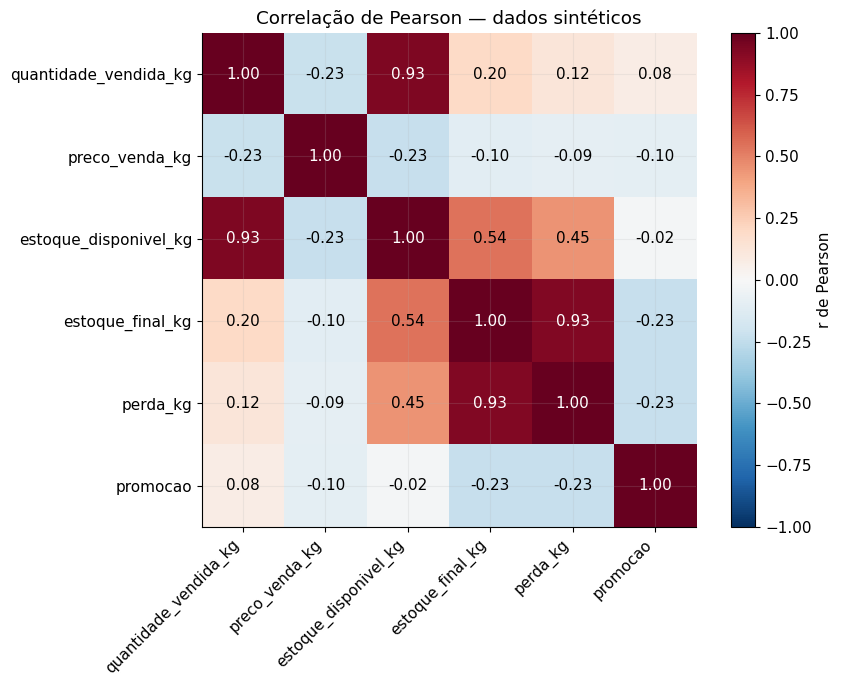

Associações são exploratórias. Disponibilidade e vendas compartilham fatores de geração, e o estoque limita o volume vendido.


In [18]:
corr_fields = ["quantidade_vendida_kg", "preco_venda_kg", "estoque_disponivel_kg", "estoque_final_kg", "perda_kg", "promocao"]
corr = df[corr_fields].corr()
display(corr.round(3))
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr_fields)), corr_fields, rotation=45, ha="right")
ax.set_yticks(range(len(corr_fields)), corr_fields)
for i in range(len(corr_fields)):
    for j in range(len(corr_fields)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", color="white" if abs(corr.iloc[i,j]) > .6 else "black")
ax.set_title("Correlação de Pearson — dados sintéticos")
fig.colorbar(im, ax=ax, label="r de Pearson")
save("08_correlacoes.png")
print("Associações são exploratórias. Disponibilidade e vendas compartilham fatores de geração, e o estoque limita o volume vendido.")


## 20. Principais achados
Resultados calculados diretamente da base tratada, sujeitos às premissas do gerador.

In [19]:
print(f"Volume total: {summary['venda_kg']:.2f} kg; receita bruta: R$ {summary['receita_bruta_rs']:.2f}; perdas: {summary['perdas_kg']:.2f} kg.")
print(f"Maior volume por corte: {by_cut.venda_kg.idxmax()}; maior média mensal: {monthly.media_diaria_kg.idxmax():%Y-%m}.")
print(f"Ruptura em {summary['ruptura_pct']:.2f}% dos dias/corte: vendas não representam toda a demanda simulada.")
(ROOT / "reports").mkdir(exist_ok=True)
(ROOT / "reports/resumo_eda.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2, sort_keys=True) + "\n", encoding="utf-8")
by_cut.round(4).to_csv(ROOT / "reports/indicadores_por_corte.csv", lineterminator="\n")
monthly.round(4).to_csv(ROOT / "reports/indicadores_mensais.csv", lineterminator="\n")


Volume total: 114254.29 kg; receita bruta: R$ 5275616.69; perdas: 371.71 kg.
Maior volume por corte: Acém; maior média mensal: 2025-12.
Ruptura em 16.20% dos dias/corte: vendas não representam toda a demanda simulada.


## 21. Limitações
- Dados sintéticos, sem histórico comercial real nem validação independente das fontes de calibração.
- Um único ano e sazonalidade imposta pelo gerador; não há comprovação de recorrência ou generalização.
- Vendas censuradas por estoque; demanda latente não foi usada.
- Promoções não foram aleatorizadas para inferência causal.
- Custos e margens são estimados; não representam lucro líquido.
- UAT não realizado; redução de desperdício e impacto social/ambiental permanecem potenciais.
- Saldo, perdas, ruptura e valores derivados da venda do dia não são features válidas para previsão anterior à operação.

## 22. Próximos passos
Concluir avaliação acadêmica e, em fase posterior, obter autorização para dados anonimizados, validar necessidades com usuários, definir instante/horizonte de previsão e atributos disponíveis, construir baseline e divisão temporal, avaliar MAE/RMSE e considerar MAPE apenas quando adequado. Nenhum modelo foi treinado nesta EDA.

Referências do projeto: [README oficial do dataset](../README_dataset_iacarne.md), [regras do ETL](../data/README.md), [requisitos](../docs/requisitos.md).